



# ★★★ Codes
##  - Peak detection method: 
The method is used in the data analysis, as well as in the numerical 

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack
from astropy.modeling.powerlaws import LogParabola1D
from astropy.modeling import models, fitting
from astropy import units as u
from scipy.optimize import curve_fit

nconsecutive = 3
def get_consecutive_bins(s,nconsecutive ):

  for i in range(0,len(s)-nconsecutive+1):
  # for i in range(0,len(s)-nconsecutive):
      if np.all(s[i:i+nconsecutive] > 1.0):
        #   print(i)
        #   print(s[i:i+nconsecutive])
        #   print('---')
          return i
      
  return -1

## - Utility functions

### Gaussian
### Red.Chisq. calculation
### plotSED

In [20]:

def gaussian(x, amplitude, mu, sigma):
    # return (1.0 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2) : Normal distribution
    return amplitude * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def calc_reduced_chi_square(fit, x, y, yerr, N, n_free):
    '''
    fit (array) values for the fit
    x,y,yerr (arrays) data
    N total number of points
    n_free number of parameters we are fitting
    '''
    return 1.0/(N-n_free)*sum(((fit - y)/yerr)**2)

def plotSED(x, y, yerr, fitted_line, peakbininit, nconsecutive, residuals,reduced_chi_squared, obsdate, idx):
   # Plot the SED with the fitted line, with the residual plot at the bottom
  fig = plt.figure(figsize=(10, 6))
  frame1=fig.add_axes((.1,.3,.8,.6))
  plt.errorbar(x, y, yerr=yerr, marker='o', linestyle='', label='Data')
  plt.plot(x, fitted_line(x), '-', label='Fitted Line')
  plt.plot(x[peakbininit:peakbininit+nconsecutive],
           y[peakbininit:peakbininit+nconsecutive], label='Peak Region', marker='x', linestyle='-')
  plt.title(f"Observation {idx}: MJD {int(obsdate)} "+ r"$\chi^2$/ndf=" +f" {reduced_chi_squared:.2f}")
  # plt.xlabel('Energy [MeV]')
  plt.ylabel(r"E$^2d\phi/d$E [MeV/cm$^{-2}$ s$^{-1}$]")
  plt.xscale('log')
  plt.yscale('log')
  plt.legend()

  frame2=fig.add_axes((.1,.1,.8,.2))  
  plt.plot(x, residuals, '.', label='Residuals')
  plt.axhline(0, color='red', linestyle='--', label='Zero Line')
  plt.xlabel('Energy [MeV]')
  plt.ylabel('Residuals')
  plt.xscale('log')
  plt.legend()
  plt.tight_layout()

  plt.show()

## - Estimation of the number of detected peaks 
### theoretical: via Markov Chain

14 bins from 9 to 22


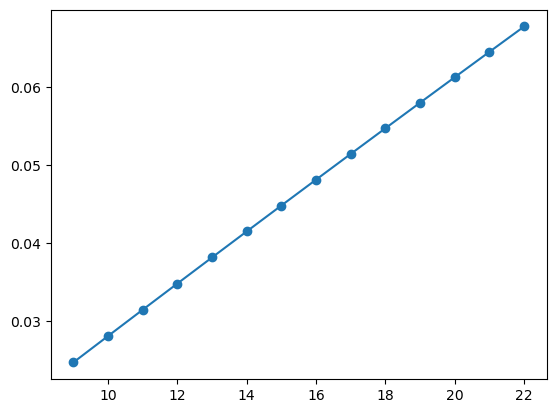

In [21]:
import numpy as np
# p=(1-0.95)/2.0
nbinsmin=9
nbinsmax=22
p=(1-0.68)/2.0
P=np.array([[1-p,p,0,0],[1-p,0,p,0],[1-p,0,0,p],[0,0,0,1]])
A=np.matrix(P)
probs = []
for ibins in range(nbinsmin, nbinsmax+1):
  B=A**ibins
  probs.append(B[0,3])

print(len(probs), "bins from", nbinsmin, "to", nbinsmax)
import matplotlib.pyplot as plt
plt.plot(range(nbinsmin, nbinsmax+1), probs, marker='o')

### numerical: via simulated residual plots

Detected peaks Distribution by simulation
 - Simulating SEDs (Residuals) based on the numbers of obs with the given data points,
 - which could be multiplied to around 1000 observations
 - Detect the peaks
 - Repeat 1000 times
 - Obtain the distribution of the number of detected peaks

In [22]:

import numpy as np

def draw_detectedPeaks_distribution(array_nbins, array_nobs, normalization=True, ntrials=1000):
  # nconsecutive = 3

  sample_normalization_factor = 1.0
  if normalization:
    sample_normalization_factor = int(1000./np.sum(array_nobs))+1
    print(1000.0/np.sum(array_nobs))
    print('sample_normalization_factor', sample_normalization_factor)

  sample_size = int(np.sum(array_nbins*array_nobs*sample_normalization_factor)*ntrials)
  array_nobs = array_nobs * sample_normalization_factor
  print('sample_size', sample_size)
  print('bins = ', array_nbins)
  print('nobs = ', array_nobs)

  #############################################
  #  Simulate all the data points of all SEDs (assuming residual plots)
  #############################################
  mu, sigma = 0, 1.0
  s = np.random.normal(mu, sigma, sample_size)

  #############################################
  #  Peak detection and counting
  #############################################
  arr_n_detected_peaks = []
  for initpos_sample, i_trial in zip(range(0,sample_size,ntrials),range(ntrials)):    
    n_detected_peaks = 0
    pos_sample = initpos_sample
    for i_nbins,i_nobs in zip(array_nbins, array_nobs):        
      for i in range(pos_sample,int(pos_sample+i_nbins*i_nobs),int(i_nbins)):          
        # print(pos_sample, i_nbins, i_nobs, i)
        # print(s[i:i+int(i_nbins)])
        peakbininit = get_consecutive_bins(s[i:i+int(i_nbins)],nconsecutive)
        if peakbininit >= 0:
          # print('A peak detected at the bin #',peakbininit)
          # plt.plot(range(peakbininit, nbins),s[i+peakbininit:i+nbins], label='obs'+str(j), marker='o',linestyle='')
          # plt.plot(range(peakbininit, peakbininit+nconsecutive),s[i+peakbininit:i+peakbininit+3], label='obs'+str(j), marker='o',linestyle='-')
          n_detected_peaks += 1
          # plt.plot(range(nbins),s[i:i+nbins], label='obs'+str(j))
      pos_sample += int(i_nbins*i_nobs)
    arr_n_detected_peaks.append(n_detected_peaks)
    print('trial',i_trial, ': n_detected_peaks=', n_detected_peaks)
  # print('Detected peaks are ', arr_n_detected_peaks)
  #############################################
  #  Fit a Gaussian distribution to the data
  #############################################
  # draw a histogram of arr_n_detected_peaks
  import matplotlib.pyplot as plt
  # plt.hist(arr_n_detected_peaks, bins=20)
  # plt.xlabel('Number of observations with detected peaks')
  # plt.ylabel('Frequency')
  # plt.title('Histogram of probability of detecting a peak')
  # plt.show()  
  from scipy.optimize import curve_fit
  nbins = 20
  n, bins, patches = plt.hist(arr_n_detected_peaks, bins = nbins)
  plt.xlabel('Number of observations with detected peaks')
  plt.ylabel('# Trials')
  plt.title('Histogram of the number of detected peaks for '+str(ntrials)+' trials')
  # plt.show()
  print('-- Distribution of number of detected peaks --')
  print('mean : ',np.mean(arr_n_detected_peaks))
  print('std  : ',np.std(arr_n_detected_peaks))
  #############################################
  #  Fit a Gaussian distribution to the data
  #############################################
#   xmin, xmax = plt.xlim()
#   x = np.linspace(xmin, xmax, nbins)
#   y = n
#   popt, pcov = curve_fit(gaussian, x, y, p0=[1, np.mean(x), np.std(x)])
#   # popt, pcov = curve_fit(gaussian, x, y)

#   plt.plot(x, gaussian(x, *popt))#, 'k', linewidth=2)
#   print('amplitude', popt[0])
#   print('mu', popt[1])
#   print('sigma', popt[2])
#   plt.yscale('log')
  plt.show()

## - Peak detection on real data

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack
from astropy.modeling.powerlaws import LogParabola1D
from astropy.modeling import models, fitting
from astropy import units as u
from scipy.optimize import curve_fit




def eval_spectra(filepath): #'data/3C454.3_allsed_14d_min11.ecsv'
  # logpar_init = LogParabola1D(amplitude=1,x_0=10,alpha=1,beta=1)
  logpar_init = LogParabola1D(
    amplitude = 0.000016494113774149846,
    x_0 = 9.482855296727278,
    alpha = -0.5677548858840729,
    beta = 0.1071613245072173)

  ### initialize a linear fitter ###
  # fit = fitting.TRFLSQFitter()
  fit = fitting.DogBoxLSQFitter()

  ### Read the data ###
  t0 = Table.read(filepath)
  nonzero_mask = (t0['e2dnde'] > t0['e2dnde_err'])
  t = t0[nonzero_mask]

  ### MJDごとに処理 ###
  obsdates=np.unique(t['tstart'].data).tolist()
  n_detected_peaks = 0
  array_nbins = []
  t_residual = Table()
  for idx, obsdate in enumerate(obsdates):
    # print(idx, ': obsdate',obsdate)
    mask = (t['tstart']==obsdate)
    x = t[mask]['e_ref']
    y = t[mask]['e2dnde']
    yerr = t[mask]['e2dnde_err']
    ### fit the data with the fitter ###
    # logpar_init.amplitude.value=x[1]*1.0e-8
    fitted_line = fit(logpar_init, x,y,weights=1.0/yerr, maxiter=200)
    residuals = (y-fitted_line(x))/yerr
    # residuals = (fitted_line(x)-y)/yerr # negative:dip finding
    peakbininit = get_consecutive_bins(residuals,nconsecutive)
    nbins = len(x)
    if nbins < nbinsmin:
        print('nbins < nbinsmin:',nbins)
        continue
    array_nbins.append(nbins)
    t_residual_ind = Table([x, residuals,np.full(len(x),obsdate)], names=[ "e_ref", "residual", "obsdate"])#"e_ref",x, "residual", residuals, "e2dnde", y, "e2dnde_err", yerr)
    t_residual = vstack([t_residual,t_residual_ind])
    reduced_chi_squared = calc_reduced_chi_square(fitted_line(x), x, y, yerr, len(x), 4)
    
    if peakbininit > 0:
      # print('peakbininit',peakbininit)
      n_detected_peaks += 1
      plotSED(x, y , yerr, fitted_line, peakbininit, nconsecutive, residuals, reduced_chi_squared, obsdate, idx)
      print(residuals[peakbininit:peakbininit+nconsecutive])
      # plt.errorbar(x,y,yerr=yerr, marker='o',linestyle='')
      # plt.plot(x,fitted_line(x),'-')
      # plt.plot(x[peakbininit:peakbininit+nconsecutive],
      #         y[peakbininit:peakbininit+nconsecutive], label='obs'+str(idx), marker='x',linestyle='-')

      # plt.title('obs'+str(idx)+':MJD'+str(int(obsdate)))
      # plt.xlabel('Energy [MeV]')
      # plt.ylabel('E^2 dN/dE [MeV cm^-2 s^-1]')
      # plt.xscale('log')
      # plt.yscale('log')
      # plt.show()

  ### bin数分布 ###
  hist_nbins = plt.hist(array_nbins, bins=np.arange(nbinsmin-0.5, nbinsmax+1.5, 1), histtype='step', lw=2)
  plt.xlabel('Number of effective bins')
  plt.ylabel('Number of SEDs')
  print('nbins distribution:')
  print(  hist_nbins[0], hist_nbins[1][0:-1]+0.5, hist_nbins[2])
  plt.show()
  
  ### detected peaks 分布 ###
  draw_detectedPeaks_distribution(hist_nbins[1][0:-1]+0.5,hist_nbins[0])
  plt.show()

  ### 各Eの residual 分布 ###
  plt.plot(t_residual['e_ref'], t_residual['residual'],'.')
  # plt.hist2d(t_residual['e_ref'], t_residual['residual'], bins=20, cmap='Blues')
  plt.xscale('log')
  plt.show()

  
  ### residual 分布 ###
  # plt.hist(t_residual['residual'], bins = 30)
  # plt.yscale('log')  
  # plt.show()
  n, bins, patches =plt.hist(t_residual['residual'], bins=np.arange(-5,5,0.2), histtype='step')
  # plt.show()

  # Fit a gaussian distribution to the data:
  xmin, xmax = plt.xlim()
  x = np.linspace(xmin, xmax, len(bins)-1)
  y = n
  popt, pcov = curve_fit(gaussian, x, y, p0=[1, np.mean(x), np.std(x)])
  # popt, pcov = curve_fit(gaussian, x, y)

  plt.plot(x, gaussian(x, *popt))#, 'k', linewidth=2)
  ymin, ymax = plt.ylim()
  plt.ylim(0.8,ymax)
  print('amplitude', popt[0])
  print('mu', popt[1])
  print('sigma', popt[2])
  plt.yscale('log')
  plt.show()

  # energies = np.unique(t_residual['e_ref'].data).tolist()
  # for energy in energies: 
  #   mask = (t_residual['e_ref']== energy)
  #   plt.hist(t_residual[mask]['residual'], bins=np.arange(-5,5,0.2), histtype='step')
  #   plt.show()


  print('Number of detected peaks:',n_detected_peaks)
  print('Number of used SEDs:',len(array_nbins))
  print('Number of SEDs:',len(obsdates))
  print('Weighted average of the probability from theory: ', np.sum(np.multiply(hist_nbins[0],probs))/len(array_nbins))

# ★★★ Execution on the data

/var/folders/xw/2d80lcgs4q70yxd586wjb4sh0000gn/T/ipykernel_39769/3978928817.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


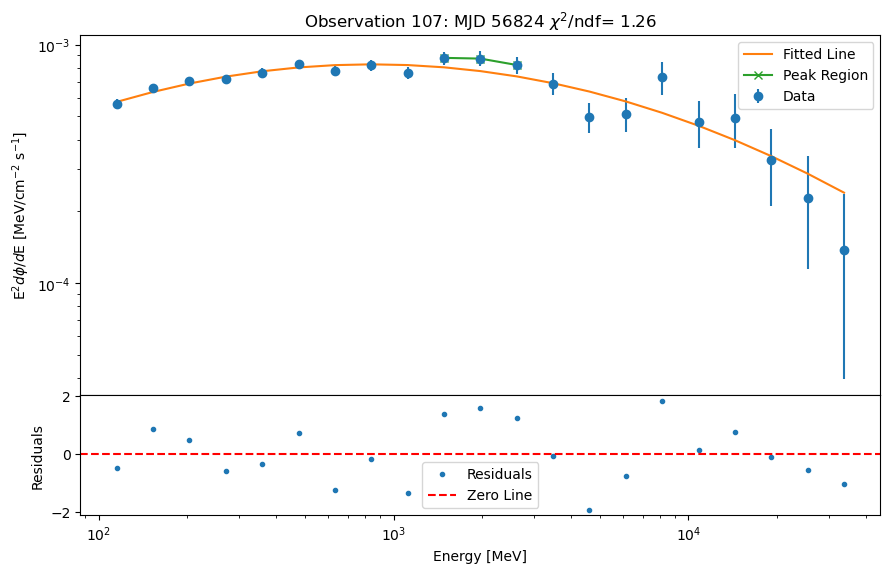

      e2dnde      
  MeV / (cm2 s)   
------------------
1.3984912943116743
1.5994265363664821
1.2420532374963023


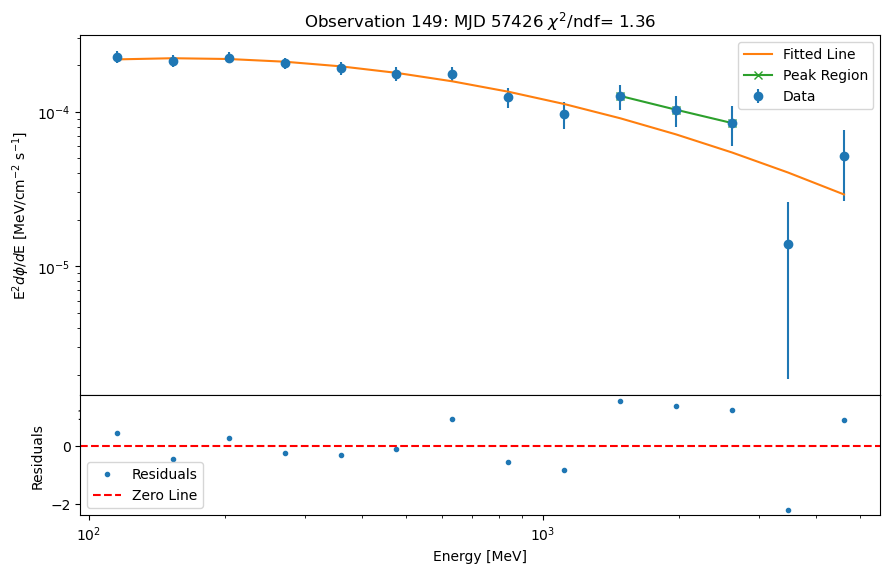

      e2dnde      
  MeV / (cm2 s)   
------------------
1.5355484056587083
1.3359096087400186
1.2257110003317486
nbins distribution:
[ 0.  9. 33. 47. 49. 42. 39. 28. 17.  8.  9.  2.  1.  0.] [ 9. 10. 11. 12. 13. 14. 15. 16. 17. 18. 19. 20. 21. 22.] [<matplotlib.patches.Polygon object at 0x12fc12dd0>]


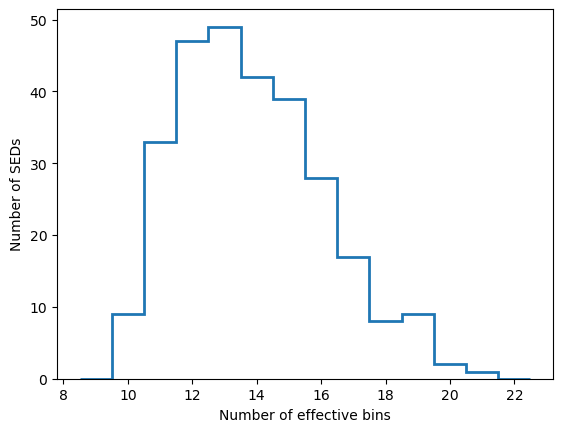

3.5211267605633805
sample_normalization_factor 4
sample_size 15760000
bins =  [ 9. 10. 11. 12. 13. 14. 15. 16. 17. 18. 19. 20. 21. 22.]
nobs =  [  0.  36. 132. 188. 196. 168. 156. 112.  68.  32.  36.   8.   4.   0.]
trial 0 : n_detected_peaks= 33
trial 1 : n_detected_peaks= 39
trial 2 : n_detected_peaks= 41
trial 3 : n_detected_peaks= 33
trial 4 : n_detected_peaks= 47
trial 5 : n_detected_peaks= 48
trial 6 : n_detected_peaks= 48
trial 7 : n_detected_peaks= 36
trial 8 : n_detected_peaks= 46
trial 9 : n_detected_peaks= 50
trial 10 : n_detected_peaks= 48
trial 11 : n_detected_peaks= 41
trial 12 : n_detected_peaks= 40
trial 13 : n_detected_peaks= 41
trial 14 : n_detected_peaks= 41
trial 15 : n_detected_peaks= 41
trial 16 : n_detected_peaks= 53
trial 17 : n_detected_peaks= 48
trial 18 : n_detected_peaks= 50
trial 19 : n_detected_peaks= 51
trial 20 : n_detected_peaks= 46
trial 21 : n_detected_peaks= 50
trial 22 : n_detected_peaks= 51
trial 23 : n_detected_peaks= 55
trial 24 : n_detected_peak

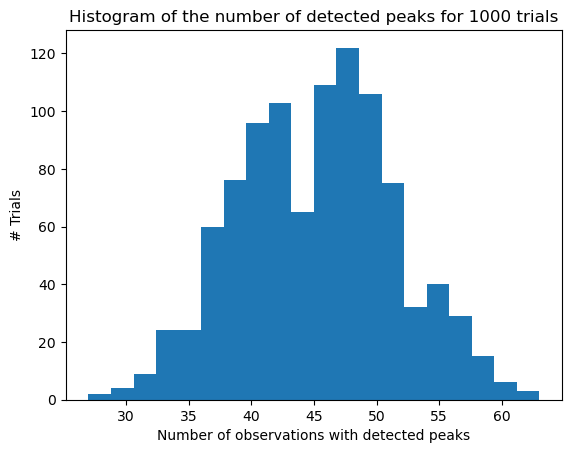

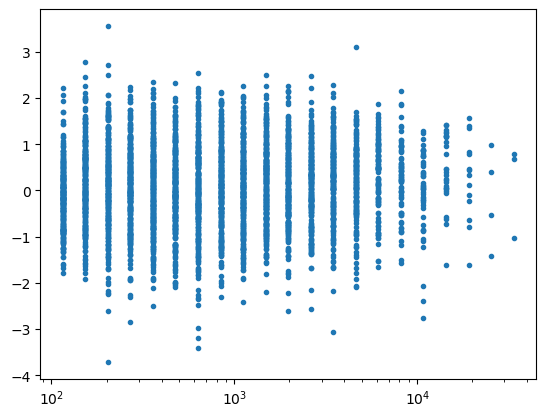

amplitudeIntel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
 357.1236011136773
mu 0.13762937300122757
sigma 0.9905633616034677


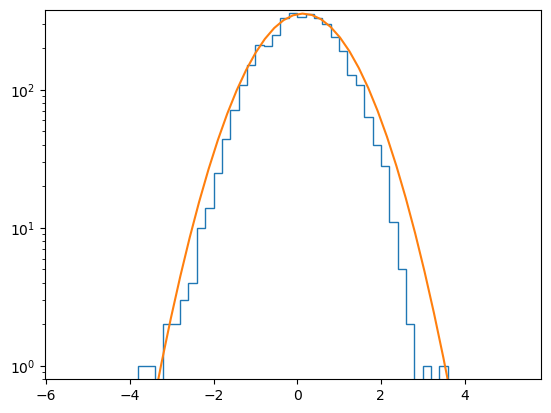

Number of detected peaks: 2
Number of used SEDs: 284
Number of SEDs: 284
Weighted average of the probability from theory:  0.04104678580839598


In [24]:
# eval_spectra('data/3C454.3_allsed_14d_min11.ecsv')  # 2pos, 0neg/264
eval_spectra('data/3C454.3_allsed_14d_min11.ecsv')  # 2pos, 0neg/264
# eval_spectra('data/3C454.3_allsed_7d_min11.ecsv')   # 3pos, 0neg/208
# eval_spectra('data/3C454.3_allsed_1d_min11.ecsv')   # 8pos, 0neg/556
# eval_spectra('data/3C454.3_allsed_1d_2_min11.ecsv') # 7pos, 0neg/461, several peaks on 56830, sudden drop on 57562

# show_SED('data/3C454.3_allsed_1d_2_min11.ecsv', 56830, 5) # show SEDs around MJD 56830
# show_SED('data/3C454.3_allsed_1d_2_min11.ecsv', 57562, 5) # show SEDs around MJD 57562


# eval_spectra('data/Mrk421_allsed_14d_min11.ecsv')   # 6pos, 1neg/394
# eval_spectra('data/CTA102_allsed_14d_min11.ecsv')   # 5pos, 1neg/180, too low in lowestE on 57790
# show_SED('data/CTA102_allsed_14d_min11.ecsv', 57790, 20) # show SEDs around MJD 57790
# eval_spectra('data/3C279_allsed_14d_min11.ecsv')    # 6pos, 0neg/260
# eval_spectra('data/4C+21.35_allsed_14d_min11.ecsv') # 0pos, 0neg /101
# eval_spectra('data/BLLac_allsed_14d_min11.ecsv')    # 5pos, 0neg/249　-> 3pos, 0neg/294
# eval_spectra('data/PKS1510-089_allsed_14d_min11.ecsv') # 2pos, 0neg/214
# eval_spectra('data/S20109+22_allsed_14d_min11.ecsv') # 0/50
# eval_spectra('data/S50716+71_allsed_14d_min11.ecsv')    # 4pos, 0neg/278
# eval_spectra('data/PKS1424-41_allsed_14d_min11.ecsv')    # 3pos, 0neg/297